In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# Data
data = pd.read_excel('/content/index.xlsx')

In [ ]:
data.head()

,date,datetime,cash_type,money,coffee_name
0,2024-03-01,0,0,38.7,7
1,2024-03-01,0,0,38.7,6
2,2024-03-01,0,0,38.7,6
3,2024-03-01,0,0,28.9,0
4,2024-03-01,0,0,38.7,7


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   int64         
 2   cash_type    3636 non-null   int64         
 3   money        3636 non-null   float64       
 4   coffee_name  3636 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 142.2 KB


In [ ]:
# Mengubah kolom 'datetime, cash_type, coffe_time' menjadi kategori
data['datetime'] = data['datetime'].astype('category')
data['cash_type'] = data['cash_type'].astype('category')
data['coffee_name'] = data['coffee_name'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   category      
 2   cash_type    3636 non-null   category      
 3   money        3636 non-null   float64       
 4   coffee_name  3636 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(1)
memory usage: 68.2 KB


In [ ]:
# pisahkan atrbut dan label
predictions = ['cash_type','money', 'coffee_name']
x = data[predictions]
y = data['datetime']

In [ ]:
# lakukan normalisasi terhadap data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
scaled_data = scaler.transform(x)
scaled_data = pd.DataFrame(scaled_data, columns=x.columns)
scaled_data.head()

,cash_type,money,coffee_name
0,-0.158403,1.413456,1.464215
1,-0.158403,1.413456,1.081009
2,-0.158403,1.413456,1.081009
3,-0.158403,-0.578718,-1.218230
4,-0.158403,1.413456,1.464215


In [ ]:
# Descriptive statistics
import matplotlib.pyplot as plt
import plotly.express as px

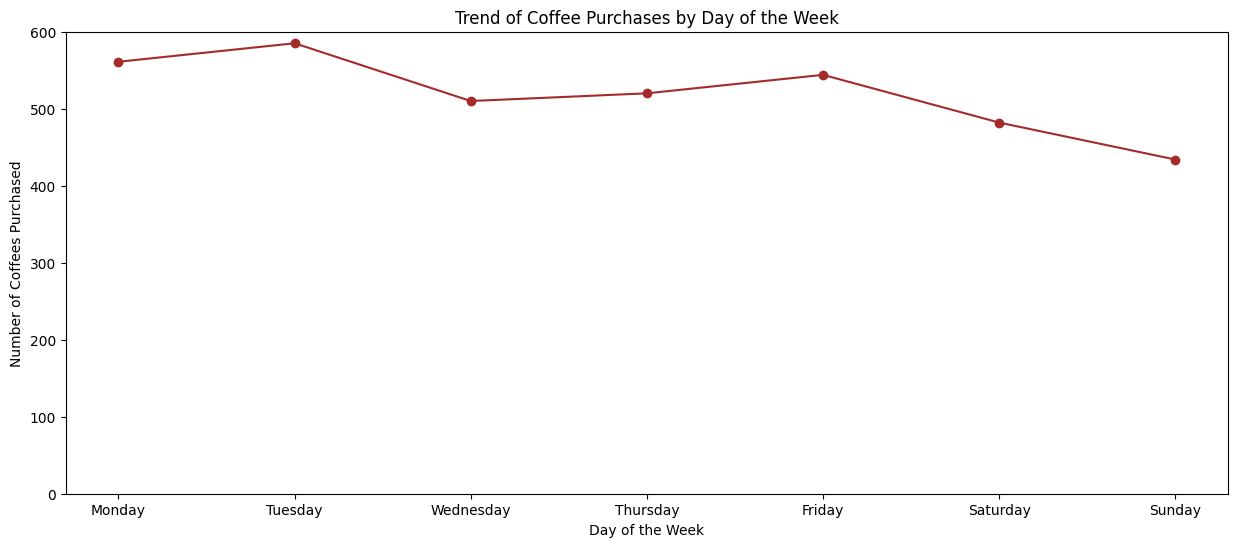

In [ ]:
#Creating a column for the day of the week.
data['day_of_week_num'] = data['date'].dt.weekday

#Group by the number of purchases by day of the week.
coffee_counts = data.groupby('day_of_week_num')['coffee_name'].count()

plt.figure(figsize=(15, 6))
plt.plot(coffee_counts.index, coffee_counts.values, marker='o', color='brown')

plt.title('Trend of Coffee Purchases by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Coffees Purchased')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday'])
plt.yticks([0,100,200,300,400,500,600])

plt.show()

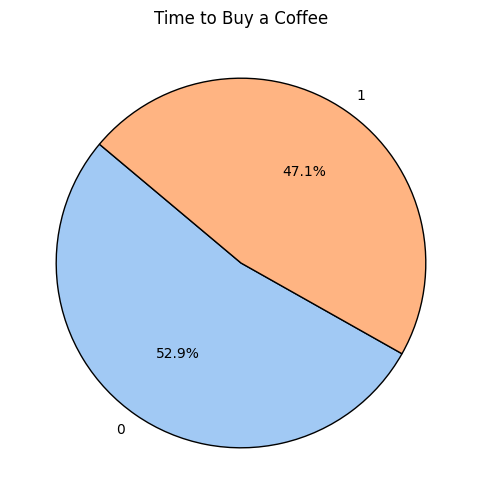

In [ ]:
# time_of_purchase
time_of_purchase = data['datetime'].value_counts()
palette = sns.color_palette("pastel", n_colors=len(time_of_purchase))
fig, ax = plt.subplots(figsize=(15, 6))
ax.pie(time_of_purchase, labels=time_of_purchase.index, autopct='%1.1f%%',
       startangle=140, colors=palette, wedgeprops={'edgecolor': 'black'})
ax.set_title("Time to Buy a Coffee")
plt.show()

In [ ]:
time_of_purchase_grouping = data.groupby(by=['datetime']).size().sort_values(ascending=False)
time_of_purchase_grouping

/tmp/ipython-input-10-97994738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_of_purchase_grouping = data.groupby(by=['datetime']).size().sort_values(ascending=False)


,0
datetime,
0,1925
1,1711


Berdasarkan diagram diatas dapat disimpulkan bahwa pembeli kopi Pembeli kopi cenderung membeli pada jam kerja. Kemungkinan disebabkan beberapa faktor termasuk dalam kebutuhan untuk tetap terjaga dan fokus selama bekerja. Karena dengan kebiasaan minum kopi sebagai bagian dari rutinitas kerja, dan ketersediaan waktu luang saat istirahat kerja untuk berkunjung ke kedai kopi. Selain itu, tren minum kopi di kalangan pekerja juga semakin meningka yang didorong oleh banyaknya kedai kopi yang menawarkan suasana yang nyaman untuk bekerja sebagai tempat bekerja atau bersosialisasi.

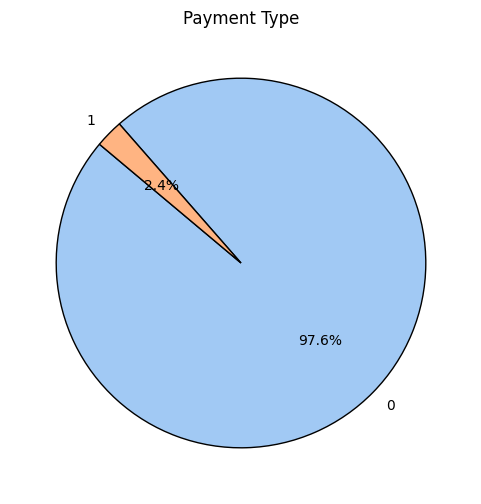

In [ ]:
# payment type
payment_type = data['cash_type'].value_counts()
palette = sns.color_palette("pastel", n_colors=len(payment_type))
fig, ax = plt.subplots(figsize=(15, 6))
ax.pie(payment_type, labels=payment_type.index, autopct='%1.1f%%',
       startangle=140, colors=palette, wedgeprops={'edgecolor': 'black'})
ax.set_title("Payment Type")
plt.show()

In [ ]:
payment_type_grouping = data.groupby(by=['cash_type']).size().sort_values(ascending=False)
payment_type_grouping

/tmp/ipython-input-12-289752310.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_type_grouping = data.groupby(by=['cash_type']).size().sort_values(ascending=False)


,0
cash_type,
0,3547
1,89


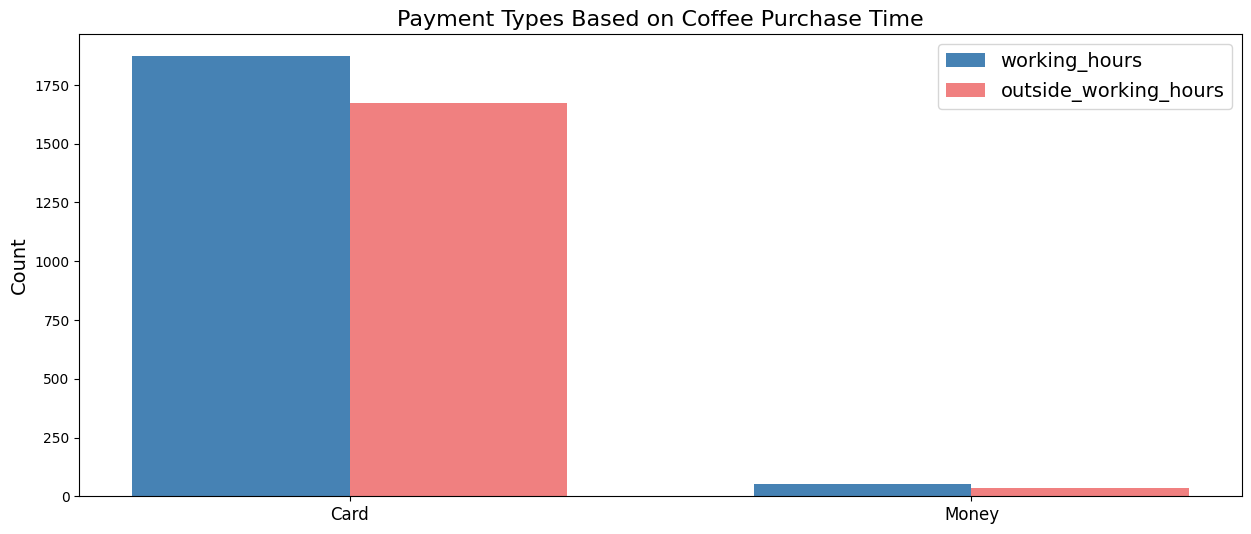

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

jenis_pembayaran = ['Card', 'Money']
working_hours = [1872, 53]
outside_working_hours = [1675, 36]

x = np.arange(len(jenis_pembayaran))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))

mhsa = ax.bar(x - width/2, working_hours, width, label='working_hours', color='steelblue')
mhsi = ax.bar(x + width/2, outside_working_hours, width, label='outside_working_hours', color='lightcoral')

ax.set_title('Payment Types Based on Coffee Purchase Time', size=16)
ax.set_ylabel('Count', size=14)
ax.set_xticks(x)
ax.set_xticklabels(jenis_pembayaran, size=12)
ax.legend(fontsize=14)

plt.show()

Dapat dilihat pada gambar bahwa dari total keseluruhan
pembeli kopi cenderung membayar dengan menggunakan Card/Cashless dibandingkan dengan Money. Hal ini kemungkinan disebabkan karena
lebih mudah, cepat, aman, dan terdapat berbagai promo menarik. Selain itu,pembayaran cashless mengurangi risiko kehilangan uang, dan memberikan akses finansial yang lebih luas. Banyak bisnis menawarkan promo khusus untuk pembayaran cashless, yang juga menjadi daya tarik tersendiri.  

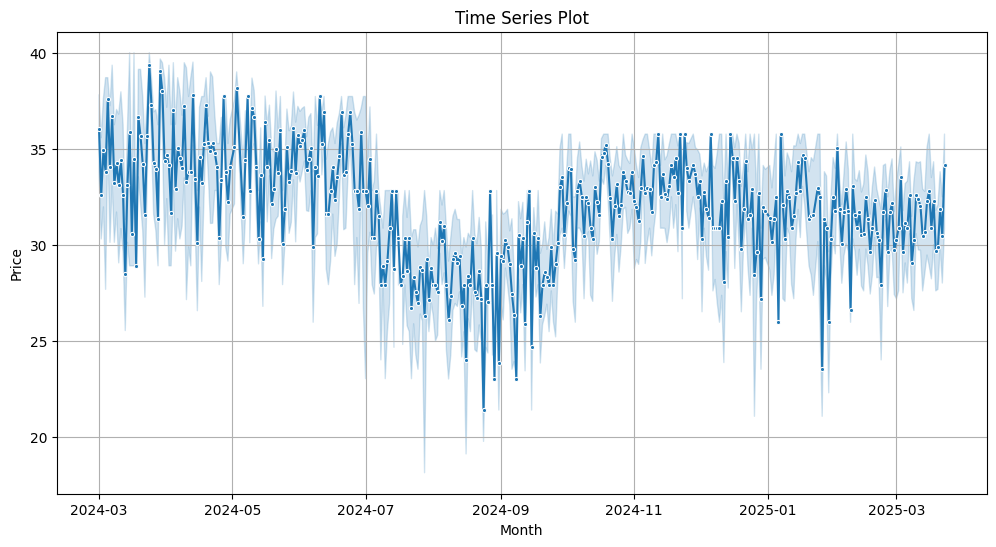

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='date', y='money', marker='.')
plt.title('Time Series Plot')
plt.xlabel('Month')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Tren pendapatan dari kurun waktu ke waktu penjualan kopi dapat menunjukkan bahwa terjadi fluktuasi permintaan kopi. Hal ini bisa disebabkan berbagai faktor seperti perubahan musim, tren gaya hidup, promosi, atau bahkan pengaruh media sosial. Misalnya, penjualan bisa meningkat pesat di musim tertentu (misalnya, saat cuaca dingin) atau karena adanya tren viral (seperti kopi Dalgona) dan kemudian menurun setelah tren tersebut mereda.

/tmp/ipython-input-19-3326406406.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coffee_grouping = data.groupby(by=['coffee_name']).size().sort_values(ascending=False)


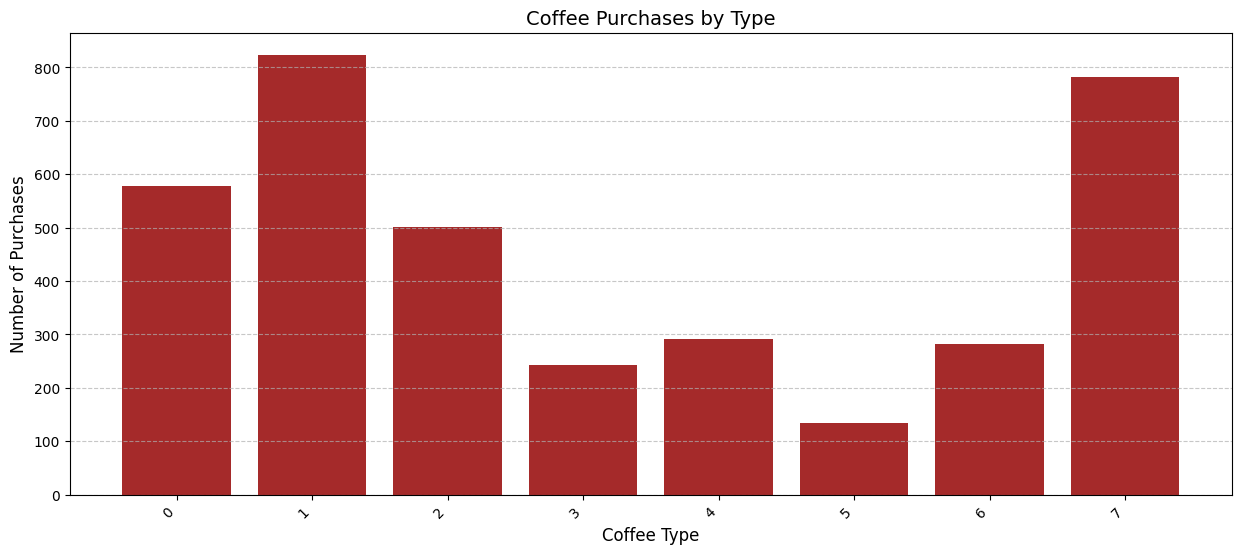

In [ ]:
# Varians Kopi Yang Terjual

#Group by the number of sales by coffee type.
coffee_grouping = data.groupby(by=['coffee_name']).size().sort_values(ascending=False)
coffee_grouping

coffee_names = coffee_grouping.index
purchase_counts = coffee_grouping.values

plt.figure(figsize=(15, 6))
plt.bar(coffee_names, purchase_counts, color='brown')

plt.xlabel("Coffee Type", fontsize=12)
plt.ylabel("Number of Purchases", fontsize=12)
plt.title("Coffee Purchases by Type", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Berdasarkan gambar type coffe yang banyak diminati oleh pembeli adalah Americano dengan susu. dan type coffe yang sedikit peminat adalah Espresso. Keungkinan pecinta kopi memilih Americano dengan susu daripada espresso karena Americano menawarkan rasa kopi yang lebih ringan dan seimbang, serta lebih mudah dinikmati dalam berbagai suhu dan kondisi. Sementara espresso cenderung memiliki rasa yang lebih kuat dan pahit.

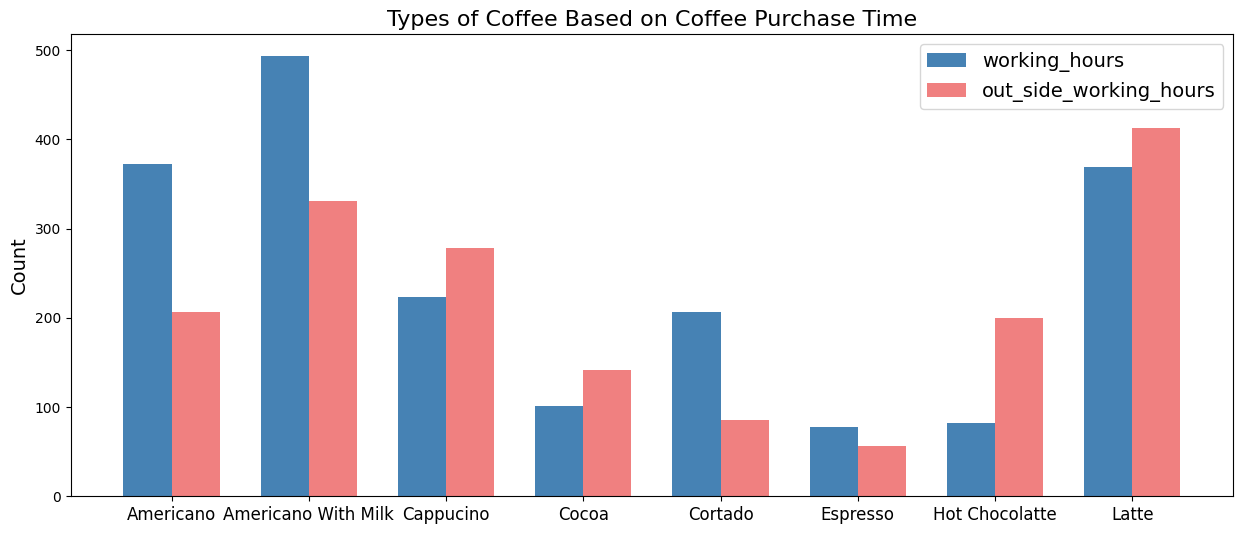

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

coffee_names = ['Americano','Americano With Milk','Cappucino','Cocoa','Cortado','Espresso','Hot Chocolatte','Latte']
working_hours = [372, 493, 223, 101, 207, 78, 82, 369]
out_side_working_hours = [206, 331, 278, 142, 85, 56, 200, 413]

x = np.arange(len(coffee_names))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))

mhsa = ax.bar(x - width/2, working_hours, width, label='working_hours', color='steelblue')
mhsi = ax.bar(x + width/2, out_side_working_hours, width, label='out_side_working_hours', color='lightcoral')

ax.set_title('Types of Coffee Based on Coffee Purchase Time', size=16)
ax.set_ylabel('Count', size=14)
ax.set_xticks(x)
ax.set_xticklabels(coffee_names, size=12)
ax.legend(fontsize=14)

plt.show()

Pembeli kopi cenderung memilih Americano dengan susu saat jam kerja karena Americano memberikan kafein yang cukup untuk menjaga fokus dan kewaspadaan, sementara susu memberikan rasa yang lebih ringan dan mudah diterima oleh sebagian orang, terutama saat mereka ingin tetap produktif. Di luar jam kerja, mereka mungkin lebih memilih latte, yang menawarkan pengalaman minum kopi yang lebih santai dan menyenangkan, dengan rasa yang lebih kaya dan tekstur yang lebih creamy, cocok untuk momen bersantai atau berkumpul.

In [ ]:
from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atibut dan label
train_data, test_data = train_test_split(data, test_size=0.2,
                                         random_state=42)

In [ ]:
# Fitting Logistic Regression

import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.glm('datetime ~ cash_type + money + coffee_name',
                data= train_data, family=sm.families.Binomial())
# Get the results of the model fit
results = model.fit()

# Print a summary of the results
print(results.summary())

                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['datetime[0]', 'datetime[1]']   No. Observations:                 2908
Model:                                        GLM   Df Residuals:                     2898
Model Family:                            Binomial   Df Model:                            9
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -1925.4
Date:                            Mon, 07 Jul 2025   Deviance:                       3850.8
Time:                                    05:38:23   Pearson chi2:                 2.91e+03
No. Iterations:                                 4   Pseudo R-squ. (CS):            0.05566
Covariance Type:                        nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----

Hasil dari uji wald dapat dilihat dengan cara membandingkan kolom signifikansi (sig.) dengan α = 0,05 (5%). Apabila tingkat signifikansi lebih kecil dari 0,05, maka H0 ditolak (signifikan). Sedangkan jika tingkat signifikansi lebih besar dari 0,05, maka H0 diterima (tidak signifikan). Ada 4 faktor yang berpengaruh terhadap waktu pembelian kopi, Faktor tersebut adalah selera pada jenis kopi cocoa, cortado,  hot chocolate, dan harga minuman kopi.

Berdasarkan hasil analisis yang dilakukan dapat disimpulkan bahwa variabel selera pada semua jenis kopi tidak berpengaruh secara signifikan terhadap keputusan konsumen dalam membeli minuman kopi. sebagaimana yang ditunjukkan dengan hasil nilai signifikan sebesar < 0,05 psehingga H0 ditolak atau dapat diartikan variabel selera tidak memberikan pengaruh secara signifikan terhadap keputusan konsumen dalam membeli minuman kopi.

Dan pada hasil analisis dapat disimpulkan bahwa variabel harga minuman Kopi
berpengaruh secara signifikan terhadap keputusan konsumen dalam membeli minuman kopi sebagaimana yang ditunjukkan dengan hasil  nilai signifikan sebesar  < 0,05 sehingga H0 ditolak atau yang berarti variabel harga minuman kopi memberikan pengaruh yang signifikan terhadap keputusan konsumen
dalam membeli minuman kopi.

In [ ]:
# Coefficient interpretation
coefficients = results.params
print(f'Coefficients: \n{coefficients}')

Coefficients: 
Intercept           1.869209
cash_type[T.1]      0.407611
coffee_name[T.1]    0.110592
coffee_name[T.2]   -0.259276
coffee_name[T.3]   -0.559954
coffee_name[T.4]    0.292540
coffee_name[T.5]   -0.452830
coffee_name[T.6]   -0.955453
coffee_name[T.7]   -0.215359
money              -0.049589
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# pisahkan atrbut dan label
predictions = ['cash_type','money', 'coffee_name']
x = data[predictions]
y = data['datetime']

# Pisahkan data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

# Inisialisasi dan latih model
model = LogisticRegression()
model.fit(X_train, y_train)

# Lakukan prediksi pada data uji
y_pred = model.predict(X_test)

# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[225 145]
 [163 195]]
Akurasi: 0.5769230769230769
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       370
           1       0.57      0.54      0.56       358

    accuracy                           0.58       728
   macro avg       0.58      0.58      0.58       728
weighted avg       0.58      0.58      0.58       728



Hasil akurasi pada penyebab berpengaruhnya selera konsumen dan harga minuman terhadap waktu pembelian kopi sebesar 58%. dan 42% lainnya kemungkinan disebabkan oleh variabel lain.

In [ ]:
data = pd.read_excel('/content/data.xlsx')

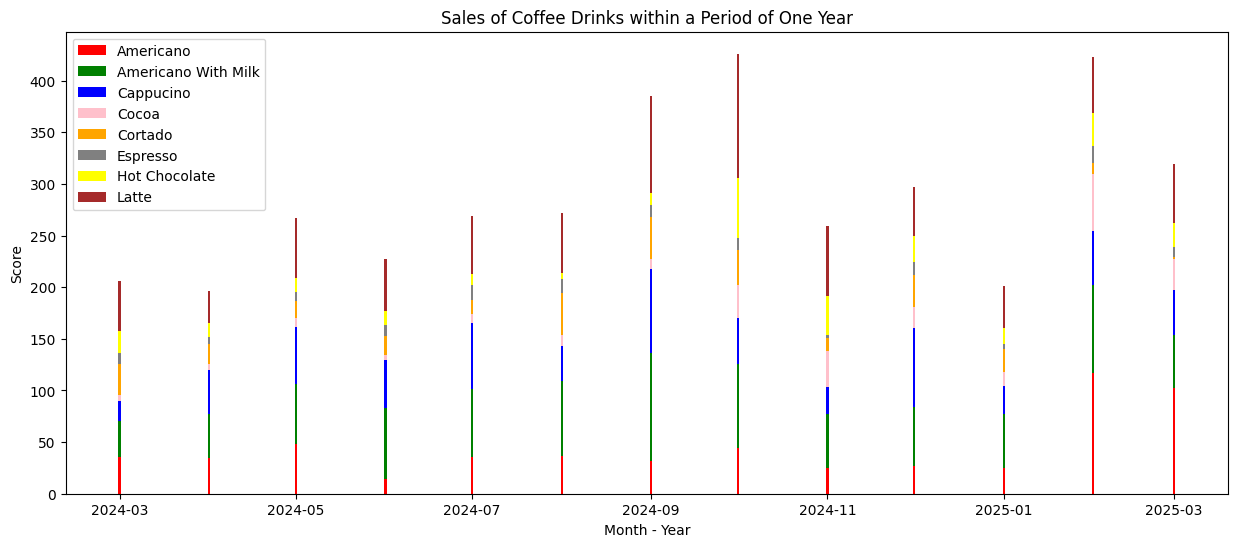

In [ ]:
# importing package
import matplotlib.pyplot as plt
import numpy as np

# create data
x = data['Bulan- Tahun']
y1 = data['Americano']
y2 = data['Americano With Milk']
y3 = data['Cappucino']
y4 = data['Cocoa']
y5 = data['Cortado']
y6 = data['Espresso']
y7 = data['Hot Chocolate']
y8 = data['Latte']

# plot bars in stack manner
fig, ax = plt.subplots(figsize=(15, 6))
plt.bar(x, y1, color='red')
plt.bar(x, y2, bottom=y1, color='green')
plt.bar(x, y3, bottom=y1+y2, color='blue')
plt.bar(x, y4, bottom=y1+y2+y3, color='pink')
plt.bar(x, y5, bottom=y1+y2+y3+y4, color='orange')
plt.bar(x, y6, bottom=y1+y2+y3+y4+y5, color='grey')
plt.bar(x, y7, bottom=y1+y2+y3+y4+y5+y6, color='yellow')
plt.bar(x, y8, bottom=y1+y2+y3+y4+y5+y6+y7, color='brown')
plt.xlabel("Month - Year")
plt.ylabel("Score")
plt.legend(["Americano", "Americano With Milk", "Cappucino", "Cocoa", "Cortado", "Espresso", "Hot Chocolate","Latte"])
plt.title("Sales of Coffee Drinks within a Period of One Year")
plt.show()

Berdasarkan grafik diatas dapat dilihat bahwa penjualan varian kopi americano with milk dan latte cenderung dominan peminat di setiap bulan. Americano dengan susu dan latte banyak diminati kemungkinan karena campuran susu yang lembut,  rasa yang lebih ringan, tekstur yang creamy, dan kemampuannya untuk disesuaikan dengan berbagai rasa tambahan. Sedangkan Cortado dan Espresso cenderung sedikit peminat karena rasa yang kuat dan tidak manis.

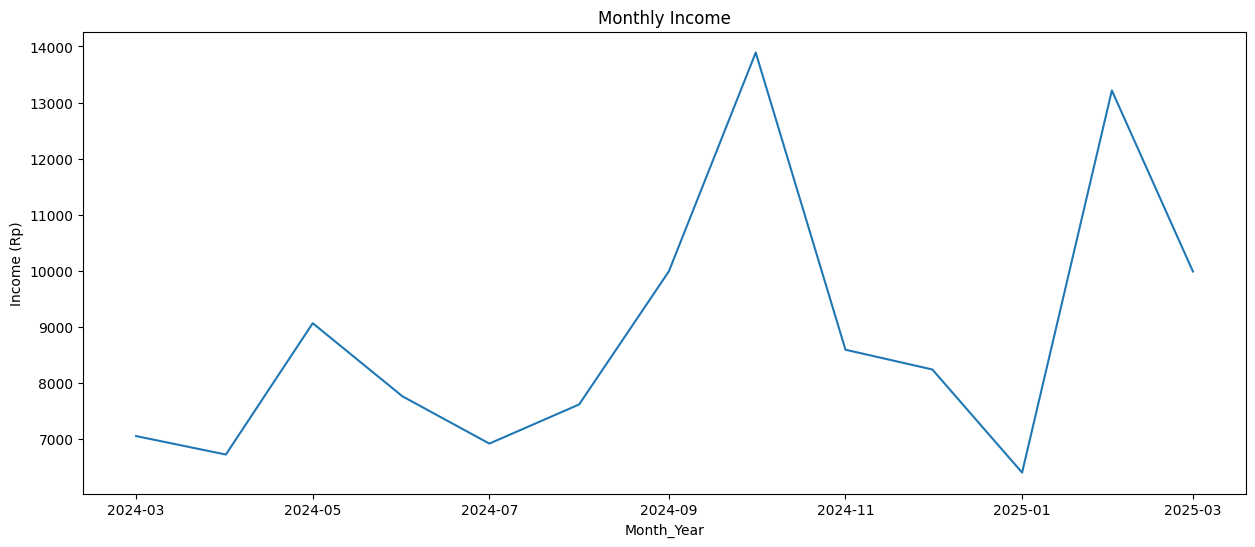

In [ ]:
import matplotlib.pyplot as plt

# Data pendapatan
Month_Year = data['Bulan- Tahun']
Income = data['Pendapatan']

# Membuat grafik garis
fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(Month_Year, Income)

# Menambahkan label dan judul
plt.xlabel('Month_Year')
plt.ylabel('Income (Rp)')
plt.title('Monthly Income')

# Menampilkan grafik
plt.show()

Dalam kurun waktu satu tahun dapat dilihat pada grafik bahwa pendapatan penjualan kopi tertinggi diperoleh pada bulan Oktober-2024.